# Exploratory Data Analysis
## Exploring CRSP Dataset
### 1. Data Integrity:

In [57]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [33]:
crsp_para = pd.read_csv('./data/2023_sp_500_select_50/combined_parameters_raw.csv')
crsp_para

,date,NDSN_RET,NDSN_VOL_CHANGE,NDSN_ASK,NDSN_BID,NDSN_sprtrn,HOLX_RET,HOLX_VOL_CHANGE,HOLX_ASK,HOLX_BID,...,MHK_RET,MHK_VOL_CHANGE,MHK_ASK,MHK_BID,MHK_sprtrn,FDS_RET,FDS_VOL_CHANGE,FDS_ASK,FDS_BID,FDS_sprtrn
0,2007-12-06,0.022113,0.175059,54.08000,53.97000,0.015037,0.032248,-0.416876,64.03,64.02,...,0.024942,-0.405355,79.43,79.35,0.015037,-0.022291,0.480991,63.51000,63.50000,0.015037
1,2007-12-07,0.004438,-0.517405,54.32000,54.21000,-0.001778,0.000156,-0.500919,64.03,63.94,...,0.006809,-0.285097,79.79,79.69,-0.001778,0.009120,0.311163,64.18000,64.09000,-0.001778
2,2007-12-10,0.015832,0.116610,55.24000,55.17000,0.007510,0.014368,-0.435645,64.95,64.92,...,0.022668,-0.157332,81.66,81.60,0.007510,0.014646,-0.310294,65.18000,65.15000,0.007510
3,2007-12-11,-0.045669,0.432598,52.75000,52.67000,-0.025271,-0.022479,0.314073,63.50,63.51,...,-0.031839,2.373966,79.06,78.99,-0.025271,-0.004453,-0.081935,64.83000,64.75000,-0.025271
4,2007-12-12,0.022598,0.106987,53.99000,53.85000,0.006050,0.018271,0.175530,64.76,64.72,...,-0.016190,-0.475887,77.82,77.61,0.006050,0.008792,0.530101,65.35000,65.28000,0.006050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4058,2023-12-22,0.008450,0.038850,261.51001,261.34000,0.001660,-0.000422,0.362391,71.05,71.03,...,0.001554,-0.469528,103.13,103.08,0.001660,-0.002233,-0.483430,468.70001,468.69000,0.001660
4059,2023-12-26,0.010025,-0.405174,263.98999,263.76999,0.004232,0.000985,-0.474035,71.13,71.10,...,-0.004558,0.859960,102.64,102.63,0.004232,0.006778,-0.276786,472.39001,472.38000,0.004232
4060,2023-12-27,0.000795,0.330596,264.23999,264.19000,0.001430,-0.002391,0.842311,70.94,70.92,...,0.009548,-0.086697,103.71,103.62,0.001430,0.004023,-0.101245,474.44000,474.17001,0.001430
4061,2023-12-28,0.001249,-0.075709,264.73001,264.51999,0.000370,0.004511,-0.359484,71.26,71.24,...,0.012063,-0.024619,104.90,104.88,0.000370,0.005441,0.391621,477.13000,477.12000,0.000370


In [3]:
print('Columns:', crsp_para.columns)
crsp_para.describe()

Columns: Index(['date', 'NDSN_RET', 'NDSN_VOL_CHANGE', 'NDSN_ASK', 'NDSN_BID',
       'NDSN_sprtrn', 'HOLX_RET', 'HOLX_VOL_CHANGE', 'HOLX_ASK', 'HOLX_BID',
       ...
       'MHK_RET', 'MHK_VOL_CHANGE', 'MHK_ASK', 'MHK_BID', 'MHK_sprtrn',
       'FDS_RET', 'FDS_VOL_CHANGE', 'FDS_ASK', 'FDS_BID', 'FDS_sprtrn'],
      dtype='object', length=251)


,NDSN_RET,NDSN_VOL_CHANGE,NDSN_ASK,NDSN_BID,NDSN_sprtrn,HOLX_RET,HOLX_VOL_CHANGE,HOLX_ASK,HOLX_BID,HOLX_sprtrn,...,MHK_RET,MHK_VOL_CHANGE,MHK_ASK,MHK_BID,MHK_sprtrn,FDS_RET,FDS_VOL_CHANGE,FDS_ASK,FDS_BID,FDS_sprtrn
count,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,...,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000
mean,0.000817,0.123234,115.064918,114.980763,0.000370,0.000431,0.119399,39.236778,39.221428,0.000370,...,0.000397,0.099735,125.693889,125.658920,0.000370,0.000658,0.091993,191.645646,191.571523,0.000370
std,0.022026,0.668460,65.728000,65.672068,0.012899,0.020800,0.670880,21.288858,21.284716,0.012899,...,0.026099,0.555480,62.464627,62.461842,0.012899,0.017807,0.613620,123.936774,123.886490,0.012899
min,-0.237286,-0.946604,20.420000,20.400000,-0.119841,-0.205274,-0.881193,9.410000,9.390000,-0.119841,...,-0.242460,-0.843026,17.130000,17.110000,-0.119841,-0.123075,-0.902859,33.260000,33.200000,-0.119841
25%,-0.008192,-0.238444,63.735000,63.665000,-0.004294,-0.008934,-0.241174,20.560000,20.550000,-0.004294,...,-0.011073,-0.231621,69.430000,69.375000,-0.004294,-0.007218,-0.224549,93.320000,93.305000,-0.004294
50%,0.000722,-0.002706,82.540000,82.510000,0.000672,0.000698,-0.016949,37.430000,37.420000,0.000672,...,0.000331,-0.006251,122.440000,122.400000,0.000672,0.001440,-0.017014,159.160000,159.120000,0.000672
75%,0.010579,0.302528,156.270000,156.210000,0.006012,0.009763,0.296620,52.785000,52.765000,0.006012,...,0.011999,0.286015,180.154995,180.100000,0.006012,0.008977,0.269393,278.175000,278.149995,0.006012
max,0.196964,12.797857,270.670010,270.370000,0.115800,0.141047,13.589685,87.670000,87.630000,0.115800,...,0.295611,8.467686,284.790010,284.690000,0.115800,0.177409,22.530243,488.859990,488.850010,0.115800


In [4]:
crsp_predictors = pd.read_csv('./data/2023_sp_500_select_50/combined_predictors_raw.csv')
crsp_predictors

,date,NDSN_BA_SPREAD,NDSN_ILLIQUIDITY,NDSN_TURNOVER,NDSN_VOL_CHANGE,NDSN_RET,NDSN_sprtrn,HOLX_BA_SPREAD,HOLX_ILLIQUIDITY,HOLX_TURNOVER,...,MHK_TURNOVER,MHK_VOL_CHANGE,MHK_RET,MHK_sprtrn,FDS_BA_SPREAD,FDS_ILLIQUIDITY,FDS_TURNOVER,FDS_VOL_CHANGE,FDS_RET,FDS_sprtrn
0,2007-12-06,0.002034,2.047758e-09,5.931001,0.175059,0.022113,0.015037,0.000156,8.561751e-11,46.712145,...,8.807433,-0.405355,0.024942,0.015037,0.000157,-6.816169e-10,10.573502,0.480991,-0.022291,0.015037
1,2007-12-07,0.002025,8.478377e-10,2.862269,-0.517405,0.004438,-0.001778,0.001406,8.297462e-13,23.313159,...,6.296459,-0.285097,0.006809,-0.001778,0.001402,2.107688e-10,13.863585,0.311163,0.009120,-0.001778
2,2007-12-10,0.001269,2.666477e-09,3.196038,0.116610,0.015832,0.007510,0.000462,1.334962e-10,13.156897,...,5.305824,-0.157332,0.022668,0.007510,0.000461,4.836728e-10,9.561802,-0.310294,0.014646,0.007510
3,2007-12-11,0.001519,-5.626003e-09,4.578638,0.432598,-0.045669,-0.025271,-0.000158,-1.625938e-10,17.289125,...,17.901668,2.373966,-0.031839,-0.025271,0.001234,-1.608980e-10,8.778351,-0.081935,-0.004453,-0.025271
4,2007-12-12,0.002600,2.459240e-09,5.068494,0.106987,0.022598,0.006050,0.000619,1.104060e-10,20.323877,...,9.382499,-0.475887,-0.016190,0.006050,0.001070,2.058087e-10,13.431762,0.530101,0.008792,0.006050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4058,2023-12-22,0.000650,1.572889e-10,3.605715,0.038850,0.008450,0.001660,0.000282,-4.281558e-12,5.780840,...,4.584639,-0.469528,0.001554,0.001660,0.000021,-1.898808e-11,6.598847,-0.483430,-0.002233,0.001660
4059,2023-12-26,0.000833,3.106019e-10,2.144772,-0.405174,0.010025,0.004232,0.000422,1.898196e-11,3.040520,...,8.527245,0.859960,-0.004558,0.004232,0.000021,7.915774e-11,4.772375,-0.276786,0.006778,0.004232
4060,2023-12-27,0.000189,1.849674e-11,2.853825,0.330596,0.000795,0.001430,0.000282,-2.507038e-11,5.601584,...,7.787962,-0.086697,0.009548,0.001430,0.000569,5.206633e-11,4.289197,-0.101245,0.004023,0.001430
4061,2023-12-28,0.000794,3.140074e-11,2.637764,-0.075709,0.001249,0.000370,0.000281,7.351389e-11,3.587905,...,7.596228,-0.024619,0.012063,0.000370,0.000021,5.032782e-11,5.968938,0.391621,0.005441,0.000370


In [5]:
# To find columns that are not present in combined_parameters dataset
crsp_para_cols = crsp_para.columns
crsp_predictors_cols = crsp_predictors.columns
diff_in_cols = []
for col in crsp_predictors_cols:
    if col not in crsp_para_cols:
        diff_in_cols.append(col)

print(diff_in_cols)

['NDSN_BA_SPREAD', 'NDSN_ILLIQUIDITY', 'NDSN_TURNOVER', 'HOLX_BA_SPREAD', 'HOLX_ILLIQUIDITY', 'HOLX_TURNOVER', 'ATO_BA_SPREAD', 'ATO_ILLIQUIDITY', 'ATO_TURNOVER', 'KIM_BA_SPREAD', 'KIM_ILLIQUIDITY', 'KIM_TURNOVER', 'NVR_BA_SPREAD', 'NVR_ILLIQUIDITY', 'NVR_TURNOVER', 'DPZ_BA_SPREAD', 'DPZ_ILLIQUIDITY', 'DPZ_TURNOVER', 'JBHT_BA_SPREAD', 'JBHT_ILLIQUIDITY', 'JBHT_TURNOVER', 'DECK_BA_SPREAD', 'DECK_ILLIQUIDITY', 'DECK_TURNOVER', 'FRT_BA_SPREAD', 'FRT_ILLIQUIDITY', 'FRT_TURNOVER', 'KMX_BA_SPREAD', 'KMX_ILLIQUIDITY', 'KMX_TURNOVER', 'EXR_BA_SPREAD', 'EXR_ILLIQUIDITY', 'EXR_TURNOVER', 'LNT_BA_SPREAD', 'LNT_ILLIQUIDITY', 'LNT_TURNOVER', 'CINF_BA_SPREAD', 'CINF_ILLIQUIDITY', 'CINF_TURNOVER', 'ED_BA_SPREAD', 'ED_ILLIQUIDITY', 'ED_TURNOVER', 'REG_BA_SPREAD', 'REG_ILLIQUIDITY', 'REG_TURNOVER', 'CPB_BA_SPREAD', 'CPB_ILLIQUIDITY', 'CPB_TURNOVER', 'LH_BA_SPREAD', 'LH_ILLIQUIDITY', 'LH_TURNOVER', 'TRMB_BA_SPREAD', 'TRMB_ILLIQUIDITY', 'TRMB_TURNOVER', 'DVA_BA_SPREAD', 'DVA_ILLIQUIDITY', 'DVA_TURNOVER',

In [6]:
# To find all tickers and features present in the datasets
tickers = []
features = []

unique_cols = []
for col in crsp_para_cols:
    if col != 'date':
        ticker = col.split("_", 1)[0]
        tickers.append(ticker)

        feature = col.split("_", 1)[1]
        features.append(feature)

tickers = set(sorted(tickers))
features = set(sorted(features))
print('Tickers present in parameters:', set(sorted(tickers)), '\n')
print('Feature present in parameters:', set(sorted(features)), '\n')

print('-' * 100)
tickers = []
features = []
for col in crsp_predictors_cols:
    if col != 'date':
        ticker = col.split("_", 1)[0]
        tickers.append(ticker)

        feature = col.split("_", 1)[1]
        features.append(feature)

tickers = set(sorted(tickers))
features = set(sorted(features))
print('Tickers present in predictors:', tickers, '\n')
print('Feature present in predictors:', features, '\n')

Tickers present in parameters: {'EXR', 'FDS', 'FFIV', 'JBHT', 'JKHY', 'CAG', 'RHI', 'STLD', 'TFX', 'HSIC', 'ETR', 'KMB', 'CINF', 'NDSN', 'EMN', 'FRT', 'IVZ', 'EXPD', 'KMX', 'DPZ', 'LH', 'MHK', 'TRV', 'IRM', 'HOLX', 'ATO', 'TECH', 'PODD', 'CHRW', 'AKAM', 'EIX', 'IEX', 'TRMB', 'COO', 'DVA', 'UHS', 'PKG', 'HBAN', 'KIM', 'BXP', 'NTRS', 'CPB', 'DECK', 'ED', 'LNT', 'ESS', 'NVR', 'CPT', 'REG', 'WRB'} 

Feature present in parameters: {'VOL_CHANGE', 'RET', 'ASK', 'sprtrn', 'BID'} 

----------------------------------------------------------------------------------------------------
Tickers present in predictors: {'EXR', 'FDS', 'FFIV', 'JBHT', 'JKHY', 'CAG', 'RHI', 'STLD', 'TFX', 'HSIC', 'ETR', 'KMB', 'CINF', 'NDSN', 'EMN', 'FRT', 'IVZ', 'EXPD', 'KMX', 'DPZ', 'LH', 'MHK', 'TRV', 'IRM', 'HOLX', 'ATO', 'TECH', 'PODD', 'CHRW', 'AKAM', 'EIX', 'IEX', 'TRMB', 'COO', 'DVA', 'UHS', 'PKG', 'HBAN', 'KIM', 'BXP', 'NTRS', 'CPB', 'DECK', 'ED', 'LNT', 'ESS', 'NVR', 'CPT', 'REG', 'WRB'} 

Feature present in pre

In [7]:
print('Number of tickers present in dataset:', len(tickers))

Number of tickers present in dataset: 50


In [8]:
crsp_predictors.describe()

,NDSN_BA_SPREAD,NDSN_ILLIQUIDITY,NDSN_TURNOVER,NDSN_VOL_CHANGE,NDSN_RET,NDSN_sprtrn,HOLX_BA_SPREAD,HOLX_ILLIQUIDITY,HOLX_TURNOVER,HOLX_VOL_CHANGE,...,MHK_TURNOVER,MHK_VOL_CHANGE,MHK_RET,MHK_sprtrn,FDS_BA_SPREAD,FDS_ILLIQUIDITY,FDS_TURNOVER,FDS_VOL_CHANGE,FDS_RET,FDS_sprtrn
count,4063.000000,4.063000e+03,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4.063000e+03,4063.000000,4063.000000,...,4063.000000,4063.000000,4063.000000,4063.000000,4063.000000,4.063000e+03,4063.000000,4063.000000,4063.000000,4063.000000
mean,0.000731,2.523047e-11,5.333412,0.123234,0.000817,0.000370,0.000483,3.618645e-12,10.546908,0.119399,...,10.969936,0.099735,0.000397,0.000370,0.000445,2.500511e-11,8.393459,0.091993,0.000658,0.000370
std,0.000924,1.369954e-09,5.655484,0.668460,0.022026,0.012899,0.000751,3.025490e-10,9.341115,0.670880,...,7.994182,0.555480,0.026099,0.012899,0.000754,4.266981e-10,6.243206,0.613620,0.017807,0.012899
min,-0.000900,-1.137370e-08,0.868338,-0.946604,-0.237286,-0.119841,-0.003477,-2.612447e-09,1.010127,-0.881193,...,1.153196,-0.843026,-0.242460,-0.119841,-0.000824,-3.979247e-09,1.125874,-0.902859,-0.123075,-0.119841
25%,0.000296,-3.448154e-10,3.011700,-0.238444,-0.008192,-0.004294,0.000249,-1.126423e-10,5.978874,-0.241174,...,6.660204,-0.231621,-0.011073,-0.004294,0.000107,-1.465242e-10,5.198576,-0.224549,-0.007218,-0.004294
50%,0.000547,2.811881e-11,4.135430,-0.002706,0.000722,0.000672,0.000391,8.336262e-12,8.246029,-0.016949,...,9.116171,-0.006251,0.000331,0.000672,0.000267,2.619031e-11,6.857402,-0.017014,0.001440,0.000672
75%,0.000917,4.275895e-10,6.085259,0.302528,0.010579,0.006012,0.000551,1.236822e-10,12.111006,0.296620,...,12.916707,0.286015,0.011999,0.006012,0.000542,1.952939e-10,9.573205,0.269393,0.008977,0.006012
max,0.041027,1.998784e-08,222.055021,12.797857,0.196964,0.115800,0.038359,2.830953e-09,212.439996,13.589685,...,165.521675,8.467686,0.295611,0.115800,0.016359,2.766379e-09,169.800064,22.530243,0.177409,0.115800


In [9]:
crsp_predictors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4063 entries, 0 to 4062
Columns: 301 entries, date to FDS_sprtrn
dtypes: float64(300), object(1)
memory usage: 9.3+ MB


In [10]:
print('First available date:', crsp_predictors['date'].min())
print('Last available date:', crsp_predictors['date'].max())

First available date: 2007-12-06
Last available date: 2023-12-29


In [11]:
# Missing values check
crsp_predictors.isna().sum().any()

np.False_

In [12]:
crsp_predictors.duplicated(subset=['date']).sum()

np.int64(19)

In [13]:
# Find all duplicated dates
duplicate_dates = crsp_predictors[crsp_predictors.duplicated(subset=['date'])]

duplicate_dates.sort_values('date')


,date,NDSN_BA_SPREAD,NDSN_ILLIQUIDITY,NDSN_TURNOVER,NDSN_VOL_CHANGE,NDSN_RET,NDSN_sprtrn,HOLX_BA_SPREAD,HOLX_ILLIQUIDITY,HOLX_TURNOVER,...,MHK_TURNOVER,MHK_VOL_CHANGE,MHK_RET,MHK_sprtrn,FDS_BA_SPREAD,FDS_ILLIQUIDITY,FDS_TURNOVER,FDS_VOL_CHANGE,FDS_RET,FDS_sprtrn
15,2007-12-27,0.000683,-5.124809e-09,3.819824,-0.173504,-0.038588,-0.014216,0.003008,-2.302592e-10,10.115841,...,4.050337,0.008746,-0.010222,-0.014216,0.000178,-2.224134e-09,6.526701,-0.281250,-0.039575,-0.014216
16,2007-12-27,0.000683,-5.124809e-09,3.819824,-0.173504,-0.038588,-0.014216,0.003008,-2.302592e-10,10.115841,...,4.050337,0.008746,-0.010222,-0.014216,0.000178,-2.224134e-09,6.526701,-0.281250,-0.039575,-0.014216
17,2007-12-27,0.000683,-5.124809e-09,3.819824,-0.173504,-0.038588,-0.014216,0.003008,-2.302592e-10,10.115841,...,4.050337,0.008746,-0.010222,-0.014216,0.000178,-2.224134e-09,6.526701,-0.281250,-0.039575,-0.014216
1267,2012-12-12,0.000807,-4.502377e-10,6.945167,0.717702,-0.012426,0.000448,0.000504,-2.765271e-10,8.510830,...,7.567333,-0.106972,0.002085,0.000448,0.000318,-5.985016e-10,7.568911,0.071314,-0.018921,0.000448
1782,2014-12-29,0.000627,3.538231e-10,1.654632,-0.290146,0.002893,0.000862,0.000371,0.000000e+00,1.288901,...,6.049810,0.623622,0.004314,0.000862,0.000281,-3.225707e-10,7.203536,2.266205,-0.013832,0.000862
2216,2016-09-16,0.000727,-1.291720e-10,8.439449,1.354110,-0.005988,-0.003772,0.000266,-1.574466e-11,25.811483,...,6.953057,0.556869,-0.005423,-0.003772,0.000283,-9.888768e-11,11.631310,1.090631,-0.008256,-0.003772
2402,2017-06-13,0.000768,2.192716e-10,9.474547,0.011359,0.014025,0.004511,0.000224,1.069332e-10,7.417162,...,4.551319,0.166297,0.010061,0.004511,0.000060,2.632479e-10,4.068123,-0.425426,0.007056,0.004511
2521,2017-11-29,0.000159,-7.645472e-10,4.669375,0.229798,-0.025891,-0.000369,0.000237,2.192318e-10,17.611940,...,4.941309,0.095377,-0.003535,-0.000369,0.000101,-2.027712e-11,6.391358,-0.147235,-0.001005,-0.000369
2563,2018-01-30,0.000207,-3.839314e-10,3.991853,0.171946,-0.012823,-0.010899,0.000232,-9.402470e-11,12.641455,...,6.510748,-0.225143,-0.002866,-0.010899,0.000050,-1.034900e-10,12.323779,-0.064701,-0.010012,-0.010899
2724,2018-09-18,0.000069,-6.325615e-12,2.583006,-0.319791,-0.000138,0.005369,0.000247,1.678372e-10,13.265718,...,15.727786,0.205612,-0.008774,0.005369,0.000043,6.628384e-11,6.839095,-0.032174,0.004051,0.005369


Note: Duplicate Dates Present

`TODO: Find how to handle these and find if the the duplicate columns are entire duplication of data.`

In [14]:
# To find zero variance or constant columns
zero_var_cols = crsp_predictors.columns[crsp_predictors.nunique() <= 1]
zero_var_cols

Index([], dtype='object')

In [15]:
# To find near zero variance columns
# Threshold set to variance < 1e-10 — adjust if needed
numeric_cols = crsp_predictors.select_dtypes(include=['number']).columns

near_zero_var = (
    crsp_predictors[numeric_cols].var()
    [crsp_predictors[numeric_cols].var() < 1e-10]
    .index.tolist()
)
near_zero_var

['NDSN_ILLIQUIDITY',
 'HOLX_ILLIQUIDITY',
 'ATO_ILLIQUIDITY',
 'KIM_ILLIQUIDITY',
 'NVR_ILLIQUIDITY',
 'DPZ_ILLIQUIDITY',
 'JBHT_ILLIQUIDITY',
 'DECK_ILLIQUIDITY',
 'FRT_ILLIQUIDITY',
 'KMX_ILLIQUIDITY',
 'EXR_ILLIQUIDITY',
 'LNT_ILLIQUIDITY',
 'CINF_ILLIQUIDITY',
 'ED_ILLIQUIDITY',
 'REG_ILLIQUIDITY',
 'CPB_ILLIQUIDITY',
 'LH_ILLIQUIDITY',
 'TRMB_ILLIQUIDITY',
 'DVA_ILLIQUIDITY',
 'PKG_ILLIQUIDITY',
 'CAG_ILLIQUIDITY',
 'NTRS_ILLIQUIDITY',
 'KMB_ILLIQUIDITY',
 'TRV_ILLIQUIDITY',
 'RHI_ILLIQUIDITY',
 'UHS_ILLIQUIDITY',
 'EMN_ILLIQUIDITY',
 'PODD_ILLIQUIDITY',
 'TECH_ILLIQUIDITY',
 'EXPD_ILLIQUIDITY',
 'WRB_ILLIQUIDITY',
 'EIX_ILLIQUIDITY',
 'STLD_ILLIQUIDITY',
 'BXP_ILLIQUIDITY',
 'CHRW_ILLIQUIDITY',
 'IVZ_ILLIQUIDITY',
 'HSIC_ILLIQUIDITY',
 'TFX_ILLIQUIDITY',
 'AKAM_ILLIQUIDITY',
 'JKHY_ILLIQUIDITY',
 'HBAN_ILLIQUIDITY',
 'ESS_ILLIQUIDITY',
 'ETR_ILLIQUIDITY',
 'FFIV_ILLIQUIDITY',
 'CPT_ILLIQUIDITY',
 'IEX_ILLIQUIDITY',
 'IRM_ILLIQUIDITY',
 'COO_ILLIQUIDITY',
 'MHK_ILLIQUIDITY',
 'FDS

### 2. Global View:
#### Cross-sectional mean and vol of returns

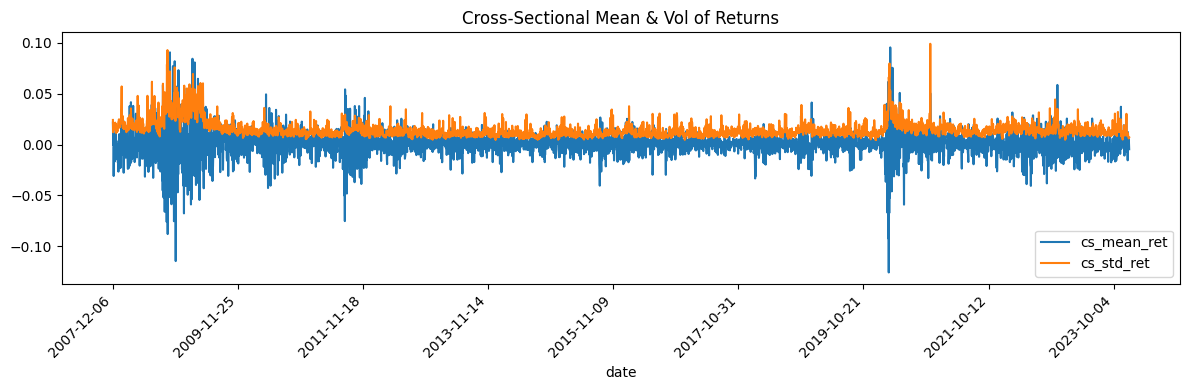

In [37]:
ret_cols = [c for c in crsp_predictors.columns if c.endswith('_RET')]
crsp_predictors['cs_mean_ret'] = crsp_predictors[ret_cols].mean(axis=1)
crsp_predictors['cs_std_ret'] = crsp_predictors[ret_cols].std(axis=1)

ax = crsp_predictors.set_index('date')[['cs_mean_ret','cs_std_ret']].plot(figsize=(12,4), title='Cross-Sectional Mean & Vol of Returns')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Cross-sectional percentiles / regime visualization
Shows how the cross-sectional spread changes (e.g., crisis widening)

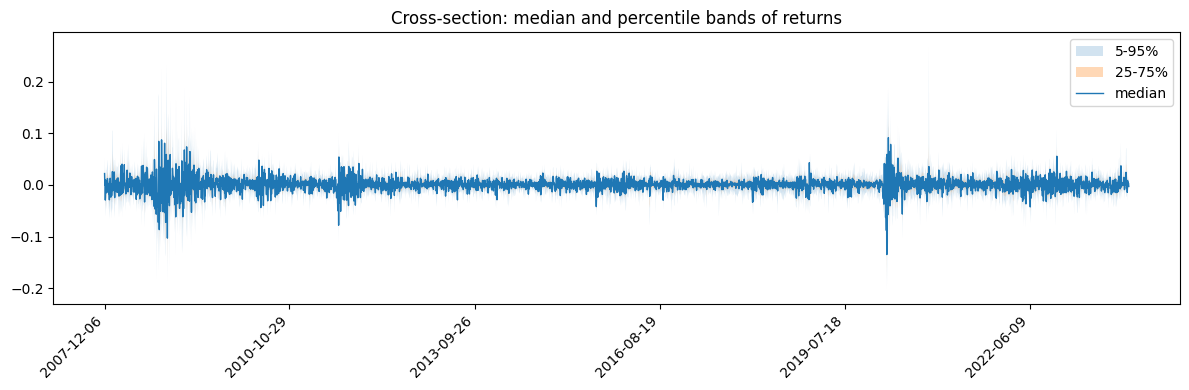

In [48]:
cs = crsp_predictors[ret_cols]
pcts = cs.quantile([0.05, 0.25, 0.5, 0.75, 0.95], axis=1).T
pcts.index = crsp_predictors['date']

fig, ax = plt.subplots(1,1,figsize=(12,4))
ax.fill_between(pcts.index, pcts[0.05], pcts[0.95], alpha=0.2, label='5-95%')
ax.fill_between(pcts.index, pcts[0.25], pcts[0.75], alpha=0.3, label='25-75%')
ax.plot(pcts.index, pcts[0.5], lw=1, label='median')
ax.set_title('Cross-section: median and percentile bands of returns')
ax.xaxis.set_major_locator(mdates.AutoDateLocator()); plt.xticks(rotation=45, ha='right')
ax.legend(); plt.tight_layout(); plt.show()

#### Breadth (fraction of stocks with positive returns)

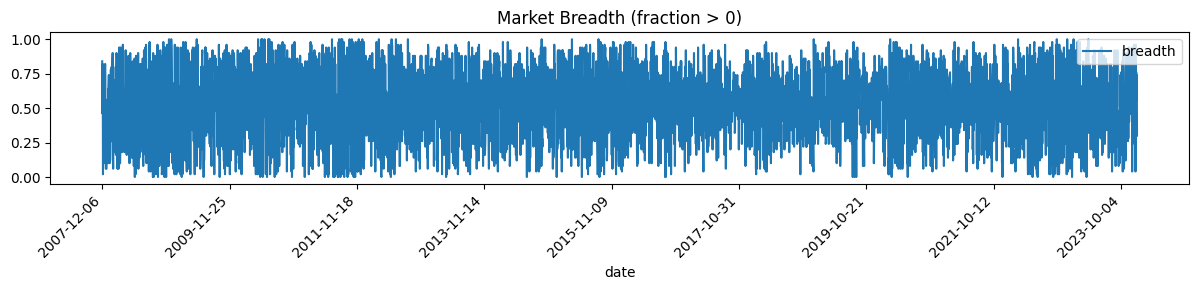

In [49]:
crsp_predictors['breadth'] = (crsp_predictors[ret_cols] > 0).mean(axis=1)
crsp_predictors.plot(x='date', y='breadth', figsize=(12,3), title='Market Breadth (fraction > 0)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

#### Cumulative (mean) return = proxy market cumulative

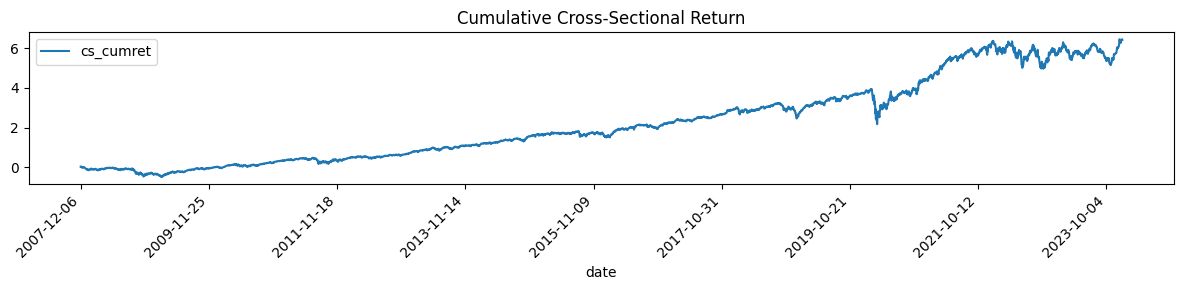

In [51]:
crsp_predictors['cs_cumret'] = (1 + crsp_predictors['cs_mean_ret']).cumprod() - 1
crsp_predictors.plot(x='date', y='cs_cumret', figsize=(12,3), title='Cumulative Cross-Sectional Return')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### PCA (market mode) + explained variance

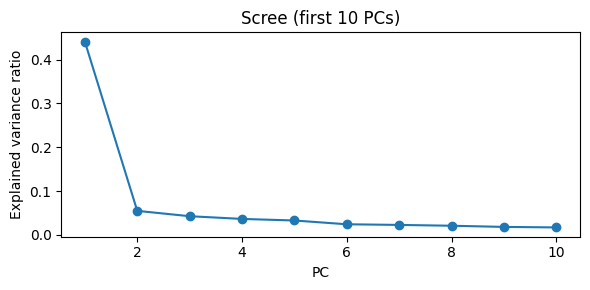

In [56]:
X = crsp_predictors[ret_cols].dropna().values
pca = PCA(n_components=10)
pca.fit(X)
plt.figure(figsize=(6,3))
plt.plot(range(1,11), pca.explained_variance_ratio_[:10], 'o-')
plt.xlabel('PC'); plt.ylabel('Explained variance ratio'); plt.title('Scree (first 10 PCs)'); plt.tight_layout(); plt.show()

#### Correlation heatmap (sampled window)
shows structure without plotting 50 time series

/var/folders/jy/90m0br910kn9mq5pnvmlc_280000gn/T/ipykernel_4254/3506033907.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  sample = crsp_predictors.set_index('date')[ret_cols].last('2YE')  # last 2 years


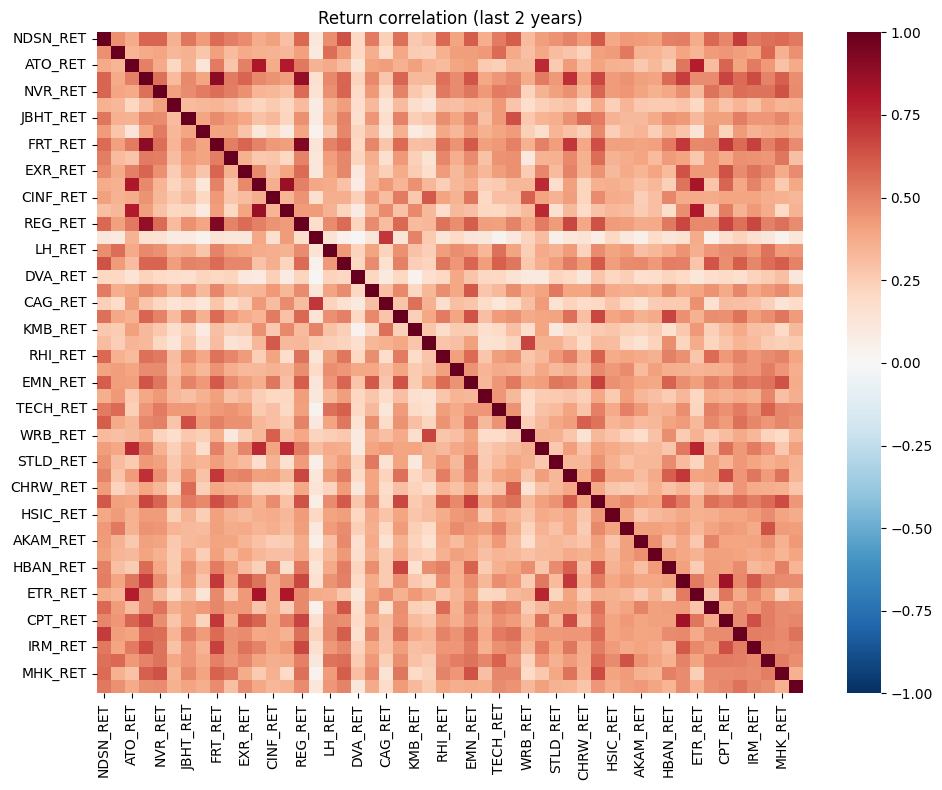

In [61]:
crsp_predictors['date'] = pd.to_datetime(crsp_predictors['date'])
sample = crsp_predictors.set_index('date')[ret_cols].last('2YE')  # last 2 years
corr = sample.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Return correlation (last 2 years)')
plt.tight_layout(); plt.show()


### Feature Distributions

<Axes: >

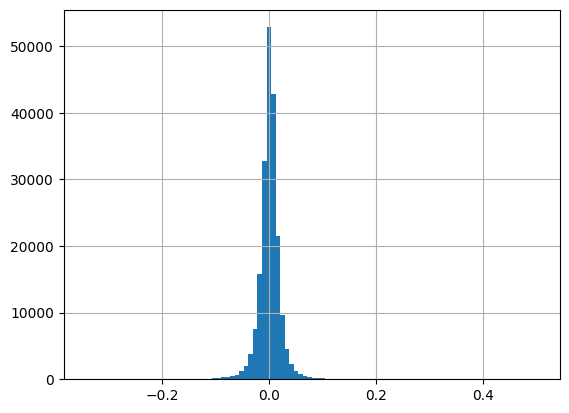

In [22]:
# Returns distribution
crsp_predictors[ret_cols].stack().hist(bins=100)

### Correlation Structure

In [25]:
corr = crsp_predictors[[c for c in crsp_predictors.columns if any(x in c for x in ["RET","VOL_CHANGE","TURNOVER","ILLIQUIDITY"])]].corr()
corr

,NDSN_ILLIQUIDITY,NDSN_TURNOVER,NDSN_VOL_CHANGE,NDSN_RET,HOLX_ILLIQUIDITY,HOLX_TURNOVER,HOLX_VOL_CHANGE,HOLX_RET,ATO_ILLIQUIDITY,ATO_TURNOVER,...,COO_VOL_CHANGE,COO_RET,MHK_ILLIQUIDITY,MHK_TURNOVER,MHK_VOL_CHANGE,MHK_RET,FDS_ILLIQUIDITY,FDS_TURNOVER,FDS_VOL_CHANGE,FDS_RET
NDSN_ILLIQUIDITY,1.000000,-0.000513,-0.015909,0.777353,0.532201,-0.017057,-0.017084,0.450349,0.477747,-0.016999,...,0.001697,0.402345,0.590578,-0.010280,-0.034651,0.493636,0.591926,0.002010,-0.027412,0.490770
NDSN_TURNOVER,-0.000513,1.000000,0.589205,0.000856,-0.021171,0.164650,0.053517,-0.021306,-0.008606,0.074036,...,0.038370,-0.017270,0.007263,0.133826,0.034740,0.004230,0.004564,0.172120,0.048026,-0.007562
NDSN_VOL_CHANGE,-0.015909,0.589205,1.000000,-0.035476,-0.026861,0.042013,0.147045,-0.020060,-0.007937,0.103426,...,0.117246,-0.006116,-0.023592,0.040385,0.140612,-0.014806,-0.015121,0.051694,0.160008,-0.015875
NDSN_RET,0.777353,0.000856,-0.035476,1.000000,0.489478,-0.005365,-0.016628,0.472119,0.404465,-0.007381,...,-0.007705,0.445501,0.533065,0.000834,-0.029338,0.509020,0.542561,-0.007676,-0.032906,0.549857
HOLX_ILLIQUIDITY,0.532201,-0.021171,-0.026861,0.489478,1.000000,-0.008186,-0.017096,0.796879,0.439878,-0.015323,...,0.006856,0.442850,0.506459,0.004407,-0.024714,0.418691,0.500669,-0.014355,-0.023546,0.440030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MHK_RET,0.493636,0.004230,-0.014806,0.509020,0.418691,-0.000402,0.012314,0.389608,0.326866,-0.013945,...,-0.016980,0.375864,0.806495,-0.021052,-0.012427,1.000000,0.426013,-0.022354,-0.042466,0.426545
FDS_ILLIQUIDITY,0.591926,0.004564,-0.015121,0.542561,0.500669,-0.000096,-0.001956,0.439028,0.470762,-0.017247,...,-0.016180,0.406865,0.522128,-0.006322,-0.034614,0.426013,1.000000,-0.050692,-0.050796,0.792732
FDS_TURNOVER,0.002010,0.172120,0.051694,-0.007676,-0.014355,0.170296,0.037406,-0.027909,-0.017024,0.077962,...,0.012328,-0.041510,-0.011237,0.204783,0.045182,-0.022354,-0.050692,1.000000,0.554751,-0.074566
FDS_VOL_CHANGE,-0.027412,0.048026,0.160008,-0.032906,-0.023546,0.034647,0.118868,-0.037402,-0.019953,0.065625,...,0.094354,-0.042402,-0.025751,0.032619,0.142704,-0.042466,-0.050796,0.554751,1.000000,-0.085492


### Univariate Analysis:

<Axes: >

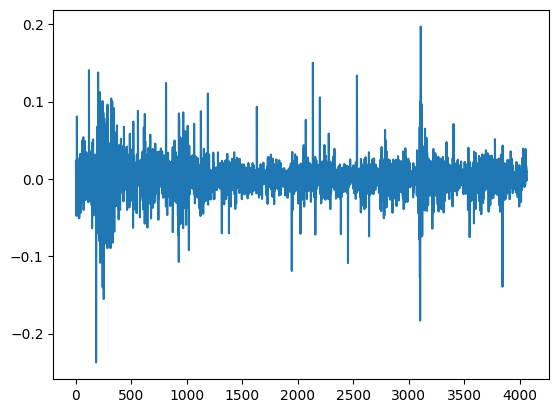

In [26]:
crsp_predictors['NDSN_RET'].plot()

Consider on ticker: NDSN,

<Axes: >

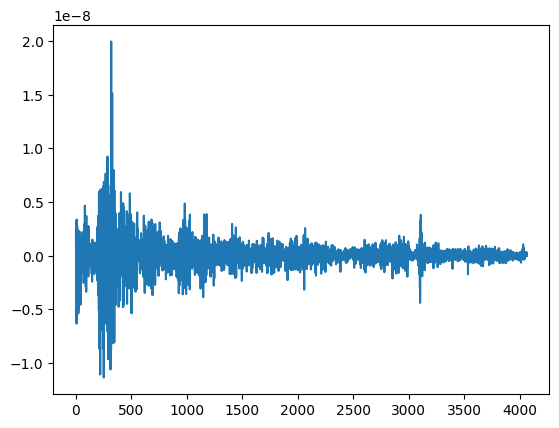

In [27]:
crsp_predictors['NDSN_ILLIQUIDITY'].plot()

<Axes: >

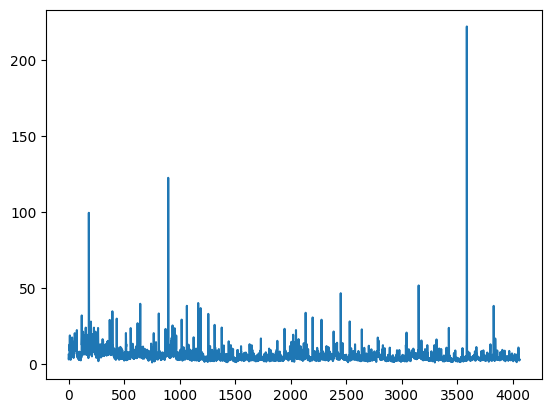

In [28]:
crsp_predictors['NDSN_TURNOVER'].plot()

<Axes: >

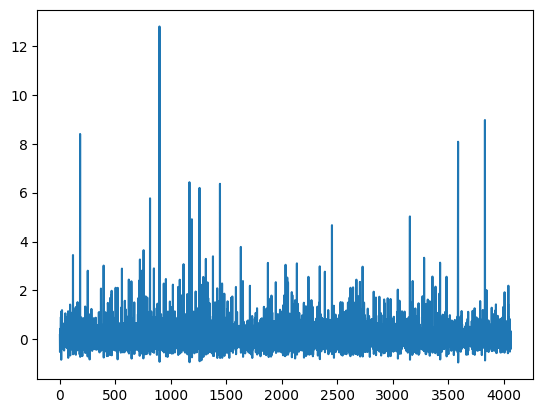

In [29]:
crsp_predictors['NDSN_VOL_CHANGE'].plot()

<Axes: >

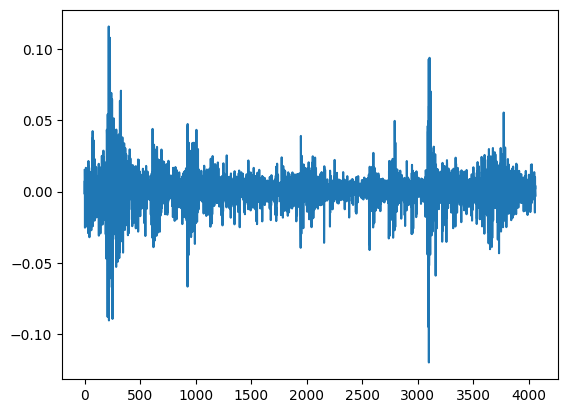

In [30]:
crsp_predictors['NDSN_sprtrn'].plot()